In [1]:
import torch
from lofi_model import LofiModel
from dataset import MidiDataset, setup_datasets_and_dataloaders
import pretty_midi
import numpy as np
from config import *
from utils import visualize_latent_space
print(torch.__version__)
print(torch.version.cuda)

c:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\venv\Lib\site-packages\pretty_midi\instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2.7.1+cu118
11.8


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model = LofiModel()
model.load_state_dict(torch.load('./saved_models/best_models/Drumms-only small Dataset SMALLER MODEL.pth'))
model.to(device)
model.eval()

LofiModel(
  (encoder): Encoder(
    (lstm): LSTM(76, 64, num_layers=2, batch_first=True, bidirectional=True)
    (fc_mean): Linear(in_features=128, out_features=64, bias=True)
    (fc_logvar): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (lstm): LSTM(76, 64, num_layers=2, batch_first=True)
    (fc): Linear(in_features=64, out_features=76, bias=True)
  )
  (fc_latent_to_hidden): Linear(in_features=64, out_features=128, bias=True)
  (fc_latent_to_cell): Linear(in_features=64, out_features=128, bias=True)
)

## Reconstruction

In [3]:
dataset_dir = r"C:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\dataset\transformed_dataset_smaller"
dataset = MidiDataset(dataset_dir, verbose=True)
train_dataloader, val_dataloader = setup_datasets_and_dataloaders(dataset_dir)

Setting up datasets and dataloaders...
Finished setting up datasets and dataloaders.




--- Visualising latent space ---
Saving plot to: latent_space.png



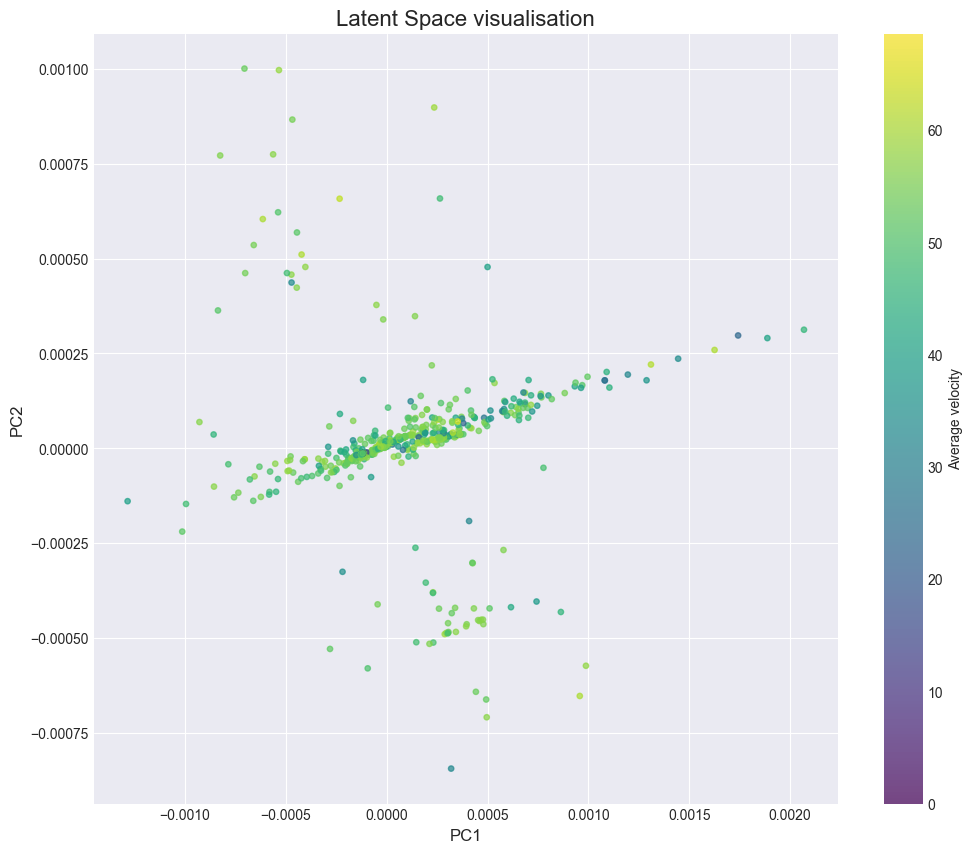

In [4]:
visualize_latent_space(model, val_dataloader)